# 03 — Análisis exploratorio: distribuciones y calidad

TFM — Emisiones de CO₂ de los vehículos nuevos matriculados en la UE.

Muestra: 1.076.533 vehículos matriculados en 2024 (10 % de la población,
muestreo pseudoaleatorio reproducible).

Objetivo: caracterizar la distribución de la variable objetivo, cuantificar
las diferencias entre tipos de combustible y detectar valores atípicos e
inconsistentes que condicionen el preprocesado. Alimenta el apartado 4.3
de la memoria.

In [2]:
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

import estilo
estilo.aplicar()

RAIZ = Path.cwd().parent
PARQUET = RAIZ / "datos" / "crudo" / "co2cars_2024_muestra1de10.parquet"
TABLA = f"'{PARQUET.as_posix()}'"

con = duckdb.connect()
total = con.execute(f"SELECT COUNT(*) FROM {TABLA}").fetchone()[0]

# Los nombres de la EEA incorporan la unidad y llevan espacios, por lo que en
# SQL deben ir entrecomillados. Se centralizan aquí para todo el cuaderno.
EWLTP  = '"Ewltp (g/km)"'
ERWLTP = '"Erwltp (g/km)"'
MASA   = '"M (kg)"'
CILIND = '"Ec (cm3)"'
POTEN  = '"Ep (KW)"'
ELECTR = '"Z (Wh/km)"'

# Etiquetas de control de la EEA, no fabricantes reales (ver sección 2)
CENTINELAS = "('DUPLICATE', 'OUT OF SCOPE', 'UNKNOWN', 'AA-IVA')"


def es(n, dec=0):
    """Formato numérico español: punto de millar y coma decimal."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "·").replace(".", ",").replace("·", ".")


MILES = FuncFormatter(lambda v, _: es(v))

print("Fichero:", PARQUET.name)
print(f"Registros: {total:,}".replace(",", "."))
print("Figuras:", estilo.DIR_FIGURAS)

Fichero: co2cars_2024_muestra1de10.parquet
Registros: 1.076.533
Figuras: C:\Users\usuario\TFM\tfm-emisiones-co2-ue\figuras


## 1. Fabricantes sin agrupación declarada

El campo `Mp` recoge la agrupación de fabricantes a efectos del objetivo de
flota y aparece vacío en una fracción no despreciable de registros. Antes de
decidir su tratamiento hay que saber a qué fabricantes corresponde: no es lo
mismo un fallo de carga que una ausencia real de agrupación.

In [3]:
q = f"""
SELECT  Mh                      AS fabricante,
        COUNT(*)                AS vehiculos,
        ROUND(AVG({EWLTP}), 1)  AS co2_medio
FROM {TABLA}
WHERE Mp IS NULL OR TRIM(Mp) = ''
GROUP BY Mh
ORDER BY vehiculos DESC
"""
sin_pool = con.execute(q).df()

print(f"Fabricantes distintos sin agrupación: {len(sin_pool)}")
print(sin_pool.head(20).to_string(index=False))
print(f"\nRepresentan {es(sin_pool['vehiculos'].sum())} de {es(total)} "
      f"({100 * sin_pool['vehiculos'].sum() / total:.2f} %)")

Fabricantes distintos sin agrupación: 56
               fabricante  vehiculos  co2_medio
                    TESLA      26297        0.0
   SAIC MOTOR CORPORATION      16278       94.7
JAGUAR LAND ROVER LIMITED       6144      118.8
           HONDA MOTOR CO       4068      109.8
                   AA-IVA       3419      150.8
                 BYD AUTO       3126        5.3
           DR AUTOMOBILES       2651      153.6
                    CHERY       1329      164.9
                      BYD       1083        0.0
                    GEELY        785       17.1
                 MASERATI        387      201.3
                  FERRARI        357      242.1
                DUPLICATE        321      119.7
                     DFSK        181      166.0
                LEAPMOTOR        169        0.0
                      NIO        138        0.0
              WUHAN LOTUS        120        0.0
             ASTON MARTIN        120      309.3
             OUT OF SCOPE        110      182.0

## 2. Etiquetas de control en el campo de fabricante

`AA-IVA`, `DUPLICATE` y `OUT OF SCOPE` no son marcas comerciales sino marcas
de control que la EEA deja en el campo `Mh`. Se mide su peso sobre el total
para justificar por escrito su exclusión.

In [4]:
q = f"""
SELECT  Mh                                          AS etiqueta,
        COUNT(*)                                    AS vehiculos,
        ROUND(100.0 * COUNT(*) / {total}, 3)        AS pct,
        ROUND(AVG({EWLTP}), 1)                      AS co2_medio,
        COUNT(DISTINCT MS)                          AS paises
FROM {TABLA}
WHERE UPPER(Mh) IN {CENTINELAS}
GROUP BY Mh
ORDER BY vehiculos DESC
"""
print(con.execute(q).df().to_string(index=False))

    etiqueta  vehiculos   pct  co2_medio  paises
      AA-IVA       3419 0.318      150.8      18
   DUPLICATE        321 0.030      119.7      21
OUT OF SCOPE        110 0.010      182.0      11
     UNKNOWN          2 0.000      123.0       1


## 3. Ceros y valores ausentes de la variable objetivo

Un cero en las emisiones puede ser un valor real —un vehículo que no emite por
el tubo de escape— o un dato ausente mal codificado. El desglose por
combustible distingue ambos casos.

In [5]:
q = f"""
SELECT  Ft                          AS combustible,
        COUNT(*)                    AS vehiculos,
        SUM(CASE WHEN {EWLTP} = 0 THEN 1 ELSE 0 END)      AS con_cero,
        SUM(CASE WHEN {EWLTP} IS NULL THEN 1 ELSE 0 END)  AS nulos
FROM {TABLA}
GROUP BY Ft
HAVING con_cero > 0 OR nulos > 0
ORDER BY con_cero DESC
"""
print(con.execute(q).df().to_string(index=False))

    combustible  vehiculos  con_cero  nulos
       electric     156307  156307.0    0.0
       hydrogen         64      64.0    0.0
         petrol     644865       0.0  774.0
            lpg      32220       0.0   16.0
diesel/electric       4623       0.0   30.0
         diesel     162307       0.0  198.0
            e85       3124       0.0    7.0
petrol/electric      72716       0.0  457.0
        unknown          5       0.0    3.0


## 4. Estadísticos descriptivos de las variables numéricas

`SUMMARIZE` recorre el fichero una sola vez. Permite detectar de un vistazo
valores fuera de rango antes de graficar.

In [6]:
resumen = con.execute(f"SUMMARIZE SELECT * FROM {TABLA}").df()

NUMERICAS = ("BIGINT", "INTEGER", "DOUBLE", "FLOAT",
             "DECIMAL", "SMALLINT", "HUGEINT")
num = resumen[resumen["column_type"].str.upper().str.startswith(NUMERICAS)]
cols = ["column_name", "count", "null_percentage",
        "min", "q25", "q50", "q75", "max", "avg", "std"]

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)
print(num[[c for c in cols if c in num.columns]].to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  column_name   count  null_percentage   min                q25                q50                q75       max                avg                std
           ID 1076533             0.00     9          147812230          151198604          157744722 161051122 152087535.71782565   5981343.18383085
       M (kg) 1076533             0.00 570.0  1280.672563899678 1483.4633914066035 1773.9954301539371    4500.0 1558.6143178678883 365.13050193614663
           Mt 1076533             1.39 616.0  1381.623581533067 1590.8531496796418 1893.1821608199702    4574.0 1670.6486484449629  381.5207336280074
 Ewltp (g/km) 1076533             0.14   0.0 101.34060118327527 122.48091022418213  137.3045006784906     543.0 106.79581841927057 58.040565035668585
 Enedc (g/km) 1076533           100.00   NaN                NaN                NaN                NaN       NaN                NaN                NaN
       W (mm) 1076533           100.00   NaN                NaN                NaN                Na

## 5. Patrón de valores ausentes por combustible

Si los nulos son estructurales deben concentrarse en los combustibles donde la
variable carece de sentido físico y ser nulos en el resto. La tabla lo verifica.

In [7]:
q = f"""
SELECT  Ft AS combustible,
        COUNT(*) AS n,
        ROUND(100.0*SUM(CASE WHEN {CILIND}  IS NULL THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_sin_cilindrada,
        ROUND(100.0*SUM(CASE WHEN Fc        IS NULL THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_sin_consumo,
        ROUND(100.0*SUM(CASE WHEN {ELECTR}  IS NULL THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_sin_kwh,
        ROUND(100.0*SUM(CASE WHEN {ERWLTP}  IS NULL THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_sin_ecoinnov
FROM {TABLA}
GROUP BY Ft
ORDER BY n DESC
"""
print(con.execute(q).df().to_string(index=False))

    combustible      n  pct_sin_cilindrada  pct_sin_consumo  pct_sin_kwh  pct_sin_ecoinnov
         petrol 644865                 0.0              0.8        100.0              30.0
         diesel 162307                 0.0              1.6        100.0              33.0
       electric 156307               100.0            100.0          1.5             100.0
petrol/electric  72716                 0.0              4.0          1.1             100.0
            lpg  32220                 0.0              0.4        100.0              11.9
diesel/electric   4623                 0.0              0.2          1.2             100.0
            e85   3124                 0.0              0.3        100.0              28.0
             ng    302                 0.0             23.8        100.0              68.5
       hydrogen     64               100.0            100.0        100.0             100.0
        unknown      5                 0.0            100.0        100.0             100.0

## 6. Distribución de las emisiones por régimen tecnológico

Se carga en memoria el subconjunto de trabajo, excluyendo las etiquetas de
control y los registros sin valor de emisiones. Los diez tipos de combustible
se agrupan en tres regímenes porque es la división que impone el reglamento:
los que no emiten por el tubo de escape, los que emiten poco por llevar
batería y enchufe, y los que emiten lo que dicta su motor térmico.

In [8]:
df = con.execute(f"""
    SELECT {EWLTP} AS ewltp, Ft AS ft, Fm AS fm, {MASA} AS masa
    FROM {TABLA}
    WHERE {EWLTP} IS NOT NULL
      AND UPPER(Mh) NOT IN {CENTINELAS}
""").df()

CERO    = ("electric", "hydrogen")
ENCHUFE = ("petrol/electric", "diesel/electric")
df["regimen"] = np.where(df["ft"].isin(CERO), "Cero emisiones",
                 np.where(df["ft"].isin(ENCHUFE), "Híbrido enchufable",
                          "Combustión"))

ORDEN_REG = ["Cero emisiones", "Híbrido enchufable", "Combustión"]
COLOR_REG = [estilo.PALETA[5], estilo.PALETA[2], estilo.PALETA[0]]

print(f"Subconjunto de trabajo: {es(len(df))} vehículos\n")
print(df["regimen"].value_counts().to_string())

Subconjunto de trabajo: 1.072.167 vehículos

regimen
Combustión            839722
Cero emisiones        155728
Híbrido enchufable     76717


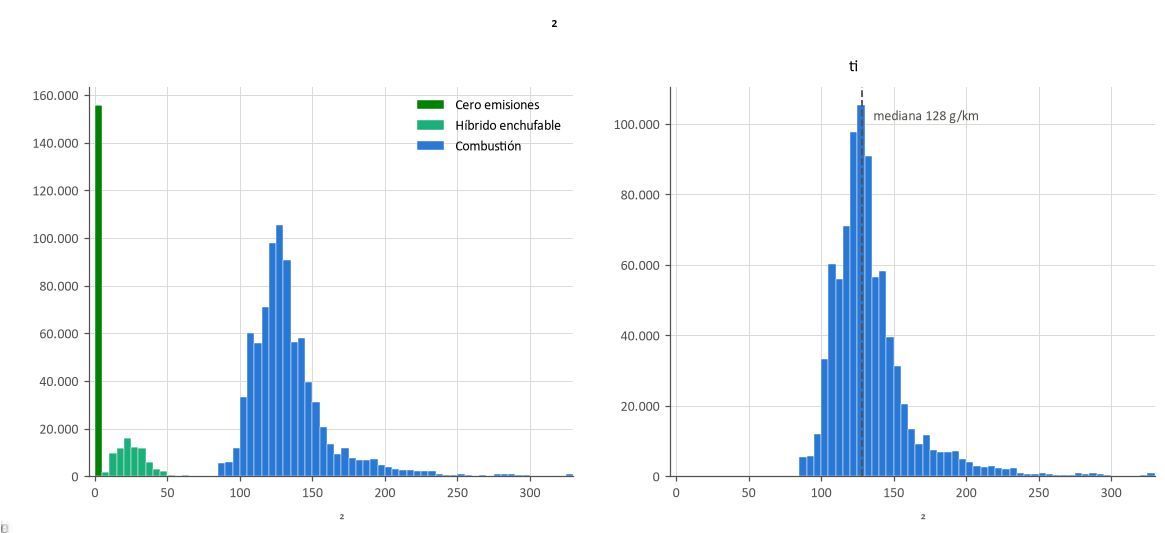

In [9]:
# El corte del eje en 330 g/km deja fuera menos del 0,1 % de los vehículos y
# se advierte en el texto de la memoria para no ocultarlo.
TOPE = 330
bins = np.linspace(0, TOPE, 67)          # anchura de 5 g/km

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

grupos = [df.loc[df["regimen"] == r, "ewltp"].clip(upper=TOPE) for r in ORDEN_REG]
ax1.hist(grupos, bins=bins, stacked=True, color=COLOR_REG,
         label=ORDEN_REG, edgecolor="white", linewidth=0.3)
ax1.set_title("Todos los vehículos", fontsize=11, pad=10, loc="left")
ax1.set_xlabel("Emisiones de CO₂ WLTP (g/km)")
ax1.set_ylabel("Vehículos")
ax1.set_xlim(-4, TOPE)
ax1.yaxis.set_major_formatter(MILES)
ax1.legend(frameon=False, fontsize=9, loc="upper right")

termicos = df.loc[df["regimen"] == "Combustión", "ewltp"]
ax2.hist(termicos.clip(upper=TOPE), bins=bins, color=estilo.PALETA[0],
         edgecolor="white", linewidth=0.3)
ax2.set_title("Solo vehículos de combustión", fontsize=11, pad=10, loc="left")
ax2.set_xlabel("Emisiones de CO₂ WLTP (g/km)")
ax2.set_xlim(-4, TOPE)
ax2.yaxis.set_major_formatter(MILES)
ax2.axvline(termicos.median(), color=estilo.GRIS_EJES, linestyle="--", linewidth=1.2)
ax2.text(termicos.median() + 8, ax2.get_ylim()[1] * 0.94,
         f"mediana {es(termicos.median())} g/km",
         fontsize=9, color=estilo.GRIS_EJES, va="top")

fig.suptitle("Distribución de las emisiones de CO₂ en turismos nuevos "
             "matriculados en la UE, 2024", fontsize=12.5, y=1.03)
fig.savefig(estilo.DIR_FIGURAS / "fig_01_distribucion_ewltp.png")
plt.show()

## 7. Emisiones por tipo de combustible

Se ordenan por mediana y se descartan las categorías con menos de mil
vehículos, que no soportan una caja interpretable. Los eléctricos se
mantienen en el eje pese a su caja degenerada: omitirlos daría una imagen
falsa del mercado.

C:\Users\usuario\AppData\Local\Temp\ipykernel_25108\3809662627.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(datos, vert=False, patch_artist=True, widths=0.62,


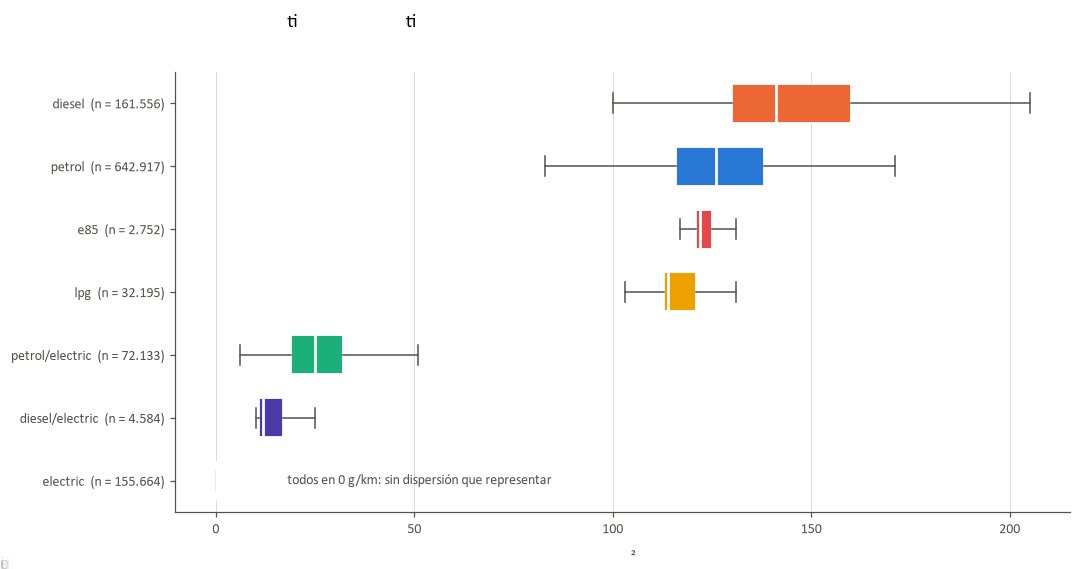

In [10]:
conteo = df["ft"].value_counts()
cats = [c for c in conteo.index if conteo[c] >= 1000]
cats = sorted(cats, key=lambda c: df.loc[df["ft"] == c, "ewltp"].median())
datos = [df.loc[df["ft"] == c, "ewltp"].values for c in cats]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
bp = ax.boxplot(datos, vert=False, patch_artist=True, widths=0.62,
                showfliers=False, medianprops=dict(color="white", linewidth=1.8))
for caja, c in zip(bp["boxes"], cats):
    caja.set_facecolor(estilo.color_de(c))
    caja.set_edgecolor("white")
    caja.set_linewidth(1.2)
for elem in ("whiskers", "caps"):
    for linea in bp[elem]:
        linea.set_color(estilo.GRIS_EJES)
        linea.set_linewidth(1.0)

ax.set_yticklabels([f"{c}  (n = {es(conteo[c])})" for c in cats], fontsize=9)
ax.set_xlabel("Emisiones de CO₂ WLTP (g/km)")
ax.xaxis.set_major_formatter(MILES)
ax.grid(axis="y", visible=False)

if "electric" in cats:
    i = cats.index("electric") + 1
    ax.annotate("todos en 0 g/km: sin dispersión que representar",
                xy=(2, i), xytext=(18, i), fontsize=9, va="center",
                color=estilo.GRIS_EJES)

ax.set_title("Emisiones por tipo de combustible\n"
             "Turismos nuevos matriculados en la UE, 2024",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_02_boxplot_combustible.png")
plt.show()

## 8. Coherencia física entre consumo y emisiones

La química de la combustión impone una relación casi fija entre litros
quemados y CO₂ emitido: en torno a 23,2 g/km por cada l/100 km en gasolina,
26,4 en gasóleo y 16,1 en GLP. Si el cociente medido reproduce esas
constantes, emisiones y consumo proceden del mismo ensayo de homologación.

In [11]:
q = f"""
SELECT  Ft                                              AS combustible,
        COUNT(*)                                        AS n,
        ROUND(AVG({EWLTP} / NULLIF(Fc, 0)), 2)          AS g_por_litro,
        ROUND(STDDEV({EWLTP} / NULLIF(Fc, 0)), 2)       AS desviacion
FROM {TABLA}
WHERE {EWLTP} > 0 AND Fc > 0
  AND UPPER(Mh) NOT IN {CENTINELAS}
GROUP BY Ft
HAVING COUNT(*) > 1000
ORDER BY n DESC
"""
print(con.execute(q).df().to_string(index=False))

    combustible      n  g_por_litro  desviacion
         petrol 639285        22.70        3.24
         diesel 159390        26.25        1.91
petrol/electric  69580        22.51        5.09
            lpg  32094        16.17        1.12
diesel/electric   4584        26.08        3.49
            e85   2752        22.68        0.23


## 9. Valores imposibles o sospechosos

Cada regla nace de una restricción física o normativa, no de un percentil
arbitrario, de modo que cada exclusión pueda justificarse por escrito.

In [12]:
reglas = {
    "masa < 800 kg (fuera del rango de turismo)":       f"{MASA} < 800",
    "masa > 3500 kg (límite legal de la categoría M1)": f"{MASA} > 3500",
    "cilindrada = 0 en vehículo térmico":               f"{CILIND} = 0 AND Ft NOT IN ('electric','hydrogen')",
    "cilindrada < 500 cm3":                             f"{CILIND} > 0 AND {CILIND} < 500",
    "potencia < 15 kW":                                 f"{POTEN} < 15",
    "potencia > 600 kW":                                f"{POTEN} > 600",
    "emisiones > 400 g/km":                             f"{EWLTP} > 400",
    "consumo = 0 en vehículo térmico":                  "Fc = 0 AND Ft NOT IN ('electric','hydrogen')",
    "emisiones = 0 en vehículo térmico":                f"{EWLTP} = 0 AND Ft NOT IN ('electric','hydrogen')",
}
filas = [{"regla": etiqueta,
          "vehiculos": con.execute(
              f"SELECT COUNT(*) FROM {TABLA} WHERE {cond}").fetchone()[0]}
         for etiqueta, cond in reglas.items()]

imposibles = pd.DataFrame(filas)
imposibles["pct"] = (100 * imposibles["vehiculos"] / total).round(4)
print(imposibles.to_string(index=False))

                                           regla  vehiculos    pct
      masa < 800 kg (fuera del rango de turismo)         24 0.0022
masa > 3500 kg (límite legal de la categoría M1)         23 0.0021
              cilindrada = 0 en vehículo térmico          0 0.0000
                            cilindrada < 500 cm3          0 0.0000
                                potencia < 15 kW       3011 0.2797
                               potencia > 600 kW        212 0.0197
                            emisiones > 400 g/km         35 0.0033
                 consumo = 0 en vehículo térmico          0 0.0000
               emisiones = 0 en vehículo térmico          0 0.0000


## 10. Potencia declarada: vehículos de menos de 15 kW

15 kW es el umbral legal que separa un turismo (categoría M1) de un
cuadriciclo pesado (L7e). Se comprueba si corresponden a microcoches o a otra
cosa, contrastando la potencia con la masa y con el modo de alimentación.

In [13]:
q = f"""
SELECT  Mk                          AS marca,
        Ft                          AS combustible,
        COUNT(*)                    AS vehiculos,
        ROUND(AVG({POTEN}), 1)      AS potencia_kw,
        ROUND(AVG({MASA}), 0)       AS masa_kg,
        ROUND(AVG({EWLTP}), 1)      AS co2_medio
FROM {TABLA}
WHERE {POTEN} < 15
GROUP BY Mk, Ft
ORDER BY vehiculos DESC
LIMIT 15
"""
print(con.execute(q).df().to_string(index=False))

# Contraste con el modo de alimentación: si se concentran en un valor de Fm
# distinto al del resto de la gasolina, Ep recoge el motor eléctrico de
# asistencia y no el térmico.
q = f"""
SELECT  CASE WHEN {POTEN} < 15 THEN 'menos de 15 kW' ELSE 'resto' END AS grupo,
        Fm                                     AS modo,
        COUNT(*)                               AS vehiculos,
        ROUND(AVG({POTEN}), 1)                 AS potencia_kw,
        ROUND(AVG({MASA}), 0)                  AS masa_kg,
        ROUND(AVG({CILIND}), 0)                AS cilindrada
FROM {TABLA}
WHERE Ft = 'petrol'
GROUP BY 1, 2
ORDER BY grupo, vehiculos DESC
"""
print("\n" + con.execute(q).df().to_string(index=False))

     marca combustible  vehiculos  potencia_kw  masa_kg  co2_medio
     DACIA      petrol       2480         12.0   1420.0      130.0
    SUZUKI      petrol        362         11.0   1287.0      124.6
   RENAULT      petrol        157         11.6   1492.0      120.7
   RENAULT      diesel          6         11.0   1758.0      136.0
VOLKSWAGEN      diesel          2         13.0   1865.0      151.0
   CITROEN      petrol          1          8.0   1291.0      134.0
 REHATRANS      diesel          1         13.0   1767.0      190.0
   PEUGEOT      diesel          1         13.0   2055.0      190.0
     HONDA      petrol          1         12.0   1710.0      132.0

         grupo modo  vehiculos  potencia_kw  masa_kg  cilindrada
menos de 15 kW    H       3000         11.9   1408.0      1221.0
menos de 15 kW    M          1          8.0   1291.0      1199.0
         resto    M     347478         96.8   1306.0      1315.0
         resto    H     294386         96.5   1452.0      1545.0


## 11. Relación entre masa y emisiones

La masa es el predictor físico dominante. Con más de ochocientos mil puntos un
diagrama de dispersión sería ilegible, por lo que se emplea un mapa de
densidad hexagonal en escala logarítmica.

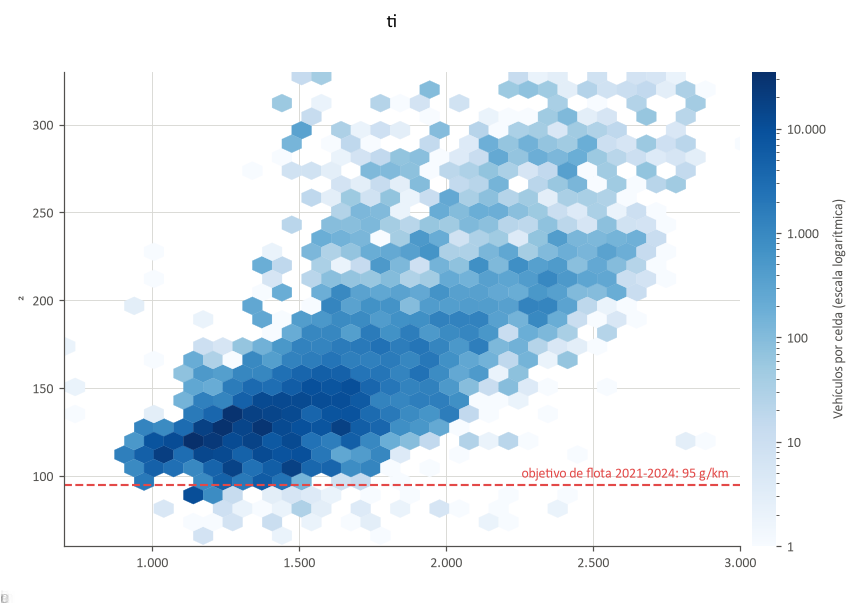

Correlación de Pearson masa–emisiones: 0.704
La masa explica por sí sola el 49.5 % de la varianza.


In [14]:
comb = df[df["regimen"] == "Combustión"].dropna(subset=["masa", "ewltp"])

fig, ax = plt.subplots(figsize=(9.5, 5.6))
hb = ax.hexbin(comb["masa"], comb["ewltp"], gridsize=55, mincnt=1,
               cmap="Blues", bins="log", linewidths=0.2)
ax.set_xlabel("Masa en orden de marcha (kg)")
ax.set_ylabel("Emisiones de CO₂ WLTP (g/km)")
ax.set_xlim(700, 3000)
ax.set_ylim(60, 330)
ax.xaxis.set_major_formatter(MILES)

ax.axhline(95, color=estilo.PALETA[7], linestyle="--", linewidth=1.4)
ax.text(2960, 99, "objetivo de flota 2021-2024: 95 g/km",
        ha="right", fontsize=9, color=estilo.PALETA[7])

cb = fig.colorbar(hb, ax=ax, pad=0.015)
cb.ax.yaxis.set_major_locator(LogLocator(base=10))
cb.ax.yaxis.set_minor_locator(LogLocator(base=10, subs="auto"))
cb.ax.yaxis.set_minor_formatter(NullFormatter())
cb.ax.yaxis.set_major_formatter(MILES)
cb.set_label("Vehículos por celda (escala logarítmica)", fontsize=9)
cb.outline.set_visible(False)

ax.set_title("Masa y emisiones en vehículos de combustión\n"
             "Turismos nuevos matriculados en la UE, 2024",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_03_masa_emisiones.png")
plt.show()

r = comb[["masa", "ewltp"]].corr().iloc[0, 1]
print(f"Correlación de Pearson masa–emisiones: {r:.3f}")
print(f"La masa explica por sí sola el {100*r**2:.1f} % de la varianza.")

In [15]:
from pathlib import Path
import pandas as pd

LIMPIO = Path.cwd().parent / "datos" / "procesado" / "co2cars_2024_limpio.parquet"

VARIABLES = {
    "Ewltp (g/km)":  "Emisiones de CO₂ (g/km)",
    "M (kg)":        "Masa en orden de marcha (kg)",
    "Mt":            "Masa de ensayo (kg)",
    "Ec (cm3)":      "Cilindrada (cm³)",
    "Ep (KW)":       "Potencia (kW)",
    "Fc":            "Consumo de combustible (l/100 km)",
    "Erwltp (g/km)": "Reducción por ecoinnovaciones (g/km)",
    "Z (Wh/km)":     "Consumo eléctrico (Wh/km)",
}

df = pd.read_parquet(LIMPIO, columns=[c for c in VARIABLES if c])

def es(x, d=2):
    return f"{x:,.{d}f}".replace(",", "@").replace(".", ",").replace("@", ".")

print(f"{'Variable':38}{'n':>12}{'Mín':>10}{'Q1':>10}{'Mediana':>10}{'Q3':>10}{'Máx':>12}{'Media':>10}{'D. típica':>11}")
for col, etiqueta in VARIABLES.items():
    s = df[col].dropna()
    q1, me, q3 = s.quantile([0.25, 0.50, 0.75])
    print(f"{etiqueta:38}{es(len(s),0):>12}{es(s.min()):>10}{es(q1):>10}"
          f"{es(me):>10}{es(q3):>10}{es(s.max()):>12}{es(s.mean()):>10}{es(s.std()):>11}")

Variable                                         n       Mín        Q1   Mediana        Q3         Máx     Media  D. típica
Emisiones de CO₂ (g/km)                  1.072.129      0,00    101,00    122,00    137,00      543,00    106,68      57,86
Masa en orden de marcha (kg)             1.072.128    831,00  1.280,00  1.482,00  1.773,00    3.300,00  1.556,87     363,60
Masa de ensayo (kg)                      1.059.488    841,00  1.381,00  1.590,00  1.893,00    3.960,00  1.670,10     381,23
Cilindrada (cm³)                           916.391    875,00  1.199,00  1.498,00  1.968,00    6.749,00  1.542,67     520,77
Potencia (kW)                            1.067.730     15,00     74,00    100,00    132,00      932,00    116,18      64,88
Consumo de combustible (l/100 km)          907.879      0,30      4,90      5,50      6,20       26,00      5,45       1,74
Reducción por ecoinnovaciones (g/km)     1.072.129      0,00      0,00      0,70      1,71        3,60      0,81       0,83
Consumo 